# Diversified Video Transformer

Copy of `video_transformer.ipynb` that trains VideoMAE with diversified weakly labeled clips. Each video contributes multiple non-overlapping temporal clips per epoch, while validation/test use deterministic multi-clip logits averaging per video.


In [49]:
from pathlib import Path
from copy import deepcopy
import math
import hashlib
import random
import warnings

import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import GradScaler, autocast
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as TF
from transformers import AutoConfig, AutoImageProcessor, VideoMAEForVideoClassification, get_cosine_schedule_with_warmup

warnings.filterwarnings("ignore", category=UserWarning)


In [50]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


PROJECT_ROOT = Path(r"E:/m-hvc")
DATASET_DIR = PROJECT_ROOT / "datasets" / "old-dataset"
DIVERSIFIED_DIR = PROJECT_ROOT / "datasets" / "diversified"
MANIFEST_PATH = DIVERSIFIED_DIR / "video_index.csv"
SPLITS_PATH = DIVERSIFIED_DIR / "splits.csv"
MATERIALIZED_CLIP_INDEX_PATH = DIVERSIFIED_DIR / "materialized_clip_index.csv"
MATERIALIZED_CLIPS_DIR = DIVERSIFIED_DIR / "clips"
FRAMES_ROOT = DATASET_DIR / "frames_unique"

NOTEBOOK_DIR = PROJECT_ROOT / "multimodal-hvc" / "hate_non_hate_vision_classification"
CHECKPOINT_DIR = NOTEBOOK_DIR / "checkpoints_t_diversified_v2"
BASE_REPORT_DIR = NOTEBOOK_DIR / "reports_diversified_v2"
REPORT_DIR = BASE_REPORT_DIR
CHECKPOINT_PATH = CHECKPOINT_DIR / "best_video_transformer_diversified.pt"
LAST_CHECKPOINT_PATH = CHECKPOINT_DIR / "last_video_transformer_diversified.pt"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
BASE_REPORT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"

CFG = {
    "seed": 42,
    "model_name": "MCG-NJU/videomae-base-finetuned-kinetics",
    "fallback_model_names": ["MCG-NJU/videomae-large-finetuned-kinetics"],
    "num_frames": 16,
    "source_clip_lengths": [16, 24, 32],
    "temporal_strides": [1, 2, 3, 4],
    "image_size": 224,
    "batch_size": 4,
    "accum_steps": 12,
    "num_workers": 0,
    "epochs": 16,
    "freeze_epochs": 1,
    "unfreeze_last_n_blocks": 2,
    "clips_per_video_train": 3,
    "multi_clip_eval": 5,
    "eval_stride": 2,
    "min_start_gap_fraction": 0.25,
    "resample_attempts": 32,
    "val_size": 0.15,
    "test_size": 0.15,
    "head_lr": 1e-5,
    "backbone_lr": 3e-7,
    "weight_decay": 5e-4,
    "warmup_ratio": 0.08,
    "grad_clip": 0.8,
    "patience": 3,
    "ema_decay": 0.999,
    "use_weighted_sampler": True,
    "sampler_weight_cap": 4.0,
    "hard_video_multiplier": 1.75,
    "threshold_min": 0.10,
    "threshold_max": 0.90,
    "threshold_steps": 81,
    "label_smoothing": 0.10,
    "class_weight_power": 0.5,
    "loss_name": "weighted_ce",  # weighted_ce or focal_ce
    "focal_gamma": 1.5,
    "head_dropout": 0.5,
    "temporal_dropout_prob": 0.15,
    "temporal_dropout_max_fraction": 0.25,
    "same_class_mix_prob": 0.08,
    "same_class_mix_alpha": 0.25,
    "random_erasing_prob": 0.15,
    "enable_hard_video_mining": True,
    "hard_video_update_interval": 2,
    "hard_low_confidence_margin": 0.10,
    "cv_folds": 5,
    "use_gradient_checkpointing": True,
    "use_torch_compile": False,
    "active_experiment": "gentle_last_block",
    "experiment_name": "gentle_last_block",
    "selection_metric": "val_f1",
    "min_delta": 0.002,
    "overwrite_main_checkpoint": False,
    "resume_from_checkpoint": True,
    "resume_checkpoint_path": str(CHECKPOINT_PATH),
    "resume_optimizer_state": False,
    "resume_additional_epochs": 8,
}

EXPERIMENT_PRESETS = {
    "baseline_reeval": {
        "experiment_name": "baseline_reeval",
        "resume_checkpoint_path": str(CHECKPOINT_PATH),
        "resume_additional_epochs": 0,
        "patience": 1,
        "overwrite_main_checkpoint": False,
    },
    "head_only_bias_correction": {
        "experiment_name": "head_only_bias_correction",
        "resume_checkpoint_path": str(CHECKPOINT_PATH),
        "resume_additional_epochs": 4,
        "freeze_epochs": 0,
        "unfreeze_last_n_blocks": 0,
        "head_lr": 1e-5,
        "backbone_lr": 0.0,
        "use_weighted_sampler": False,
        "class_weight_power": 0.0,
        "head_dropout": 0.5,
        "label_smoothing": 0.10,
        "weight_decay": 5e-4,
        "patience": 2,
        "enable_hard_video_mining": False,
        "overwrite_main_checkpoint": False,
    },
    "gentle_last_block": {
        "experiment_name": "gentle_last_block",
        "resume_checkpoint_path": str(CHECKPOINT_PATH),
        "resume_additional_epochs": 6,
        "freeze_epochs": 1,
        "unfreeze_last_n_blocks": 1,
        "head_lr": 5e-6,
        "backbone_lr": 1e-7,
        "use_weighted_sampler": False,
        "class_weight_power": 0.25,
        "head_dropout": 0.5,
        "label_smoothing": 0.08,
        "weight_decay": 5e-4,
        "random_erasing_prob": 0.10,
        "temporal_dropout_prob": 0.10,
        "patience": 2,
        "enable_hard_video_mining": False,
        "overwrite_main_checkpoint": False,
    },
    "focal_loss_last_block": {
        "experiment_name": "focal_loss_last_block",
        "resume_checkpoint_path": str(CHECKPOINT_PATH),
        "resume_additional_epochs": 6,
        "freeze_epochs": 1,
        "unfreeze_last_n_blocks": 1,
        "head_lr": 5e-6,
        "backbone_lr": 1e-7,
        "use_weighted_sampler": False,
        "class_weight_power": 0.25,
        "loss_name": "focal_ce",
        "focal_gamma": 1.0,
        "head_dropout": 0.5,
        "label_smoothing": 0.08,
        "weight_decay": 5e-4,
        "random_erasing_prob": 0.10,
        "temporal_dropout_prob": 0.10,
        "patience": 2,
        "enable_hard_video_mining": False,
        "overwrite_main_checkpoint": False,
    },
}

active_experiment = CFG.get("active_experiment", "gentle_last_block")
if active_experiment not in EXPERIMENT_PRESETS:
    raise ValueError(f"Unknown active_experiment={active_experiment!r}; choose one of {sorted(EXPERIMENT_PRESETS)}")
CFG.update(EXPERIMENT_PRESETS[active_experiment])
CFG["active_experiment"] = active_experiment

EXPERIMENT_NAME = str(CFG.get("experiment_name", active_experiment))
if CFG.get("overwrite_main_checkpoint", False):
    SAVE_CHECKPOINT_PATH = CHECKPOINT_PATH
    SAVE_LAST_CHECKPOINT_PATH = LAST_CHECKPOINT_PATH
    REPORT_DIR = BASE_REPORT_DIR
else:
    SAVE_CHECKPOINT_DIR = CHECKPOINT_DIR / "experiments" / EXPERIMENT_NAME
    SAVE_CHECKPOINT_PATH = SAVE_CHECKPOINT_DIR / "best_video_transformer_diversified.pt"
    SAVE_LAST_CHECKPOINT_PATH = SAVE_CHECKPOINT_DIR / "last_video_transformer_diversified.pt"
    REPORT_DIR = BASE_REPORT_DIR / "experiments" / EXPERIMENT_NAME
SAVE_CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

set_seed(CFG["seed"])
print(f"active experiment: {active_experiment}")
print(f"resume checkpoint: {CFG['resume_checkpoint_path']}")
print(f"save checkpoint: {SAVE_CHECKPOINT_PATH}")
print(f"report dir: {REPORT_DIR}")
print(f"device: {DEVICE}")
if torch.cuda.is_available():
    print(f"gpu: {torch.cuda.get_device_name(0)}")


active experiment: gentle_last_block
resume checkpoint: E:\m-hvc\multimodal-hvc\hate_non_hate_vision_classification\checkpoints_t_diversified_v2\best_video_transformer_diversified.pt
save checkpoint: E:\m-hvc\multimodal-hvc\hate_non_hate_vision_classification\checkpoints_t_diversified_v2\experiments\gentle_last_block\best_video_transformer_diversified.pt
report dir: E:\m-hvc\multimodal-hvc\hate_non_hate_vision_classification\reports_diversified_v2\experiments\gentle_last_block
device: cuda
gpu: NVIDIA GeForce RTX 4070


## Load Manifest And Frame Coverage

In [51]:
def numeric_frame_key(path: Path):
    stem = path.stem.split("_", 1)[0]
    return (0, int(stem)) if stem.isdigit() else (1, path.stem)


def list_frame_paths(frame_dir):
    frame_dir = Path(frame_dir)
    if not frame_dir.exists():
        return []
    paths = [path for path in frame_dir.iterdir() if path.suffix.lower() in {".jpg", ".jpeg", ".png"}]
    return sorted(paths, key=numeric_frame_key)


if MANIFEST_PATH.exists():
    clip_df = pd.read_csv(MANIFEST_PATH)
else:
    base_df = pd.read_csv(DATASET_DIR / "video_df.csv")
    base_df["source_video_id"] = base_df["source_video_id"].astype(str)
    base_df["frame_dir"] = base_df["source_video_id"].map(lambda value: str(FRAMES_ROOT / str(value)))
    base_df["num_frames"] = base_df["frame_dir"].map(lambda value: len(list_frame_paths(value)))
    clip_df = base_df[(base_df["label"].isin([0, 1])) & (base_df["num_frames"] > 0)].copy()
    clip_df.to_csv(MANIFEST_PATH, index=False)

clip_df["source_video_id"] = clip_df["source_video_id"].astype(str)
clip_df["label"] = clip_df["label"].astype(int)
if "frame_dir" not in clip_df:
    clip_df["frame_dir"] = clip_df["source_video_id"].map(lambda value: str(FRAMES_ROOT / str(value)))
if "num_frames" not in clip_df:
    clip_df["num_frames"] = clip_df["frame_dir"].map(lambda value: len(list_frame_paths(value)))
clip_df = clip_df[clip_df["num_frames"] > 0].copy().reset_index(drop=True)

assert clip_df["source_video_id"].is_unique
assert set(clip_df["label"].unique()).issubset({0, 1})

print(f"trainable videos: {len(clip_df):,}")
display(clip_df["label"].value_counts().rename_axis("label").reset_index(name="count"))
display(clip_df["num_frames"].describe().to_frame().T)


trainable videos: 3,281


,label,count
0,0,1948
1,1,1333


,count,mean,std,min,25%,50%,75%,max
num_frames,3281.0,46.509296,23.358774,1.0,28.0,64.0,64.0,64.0


## Stratified Splits

In [52]:
if SPLITS_PATH.exists():
    split_df = pd.read_csv(SPLITS_PATH)
    split_df["source_video_id"] = split_df["source_video_id"].astype(str)
    split_df["label"] = split_df["label"].astype(int)
    if "frame_dir" not in split_df:
        split_df["frame_dir"] = split_df["source_video_id"].map(lambda value: str(FRAMES_ROOT / str(value)))
    if "num_frames" not in split_df:
        split_df["num_frames"] = split_df["frame_dir"].map(lambda value: len(list_frame_paths(value)))
    train_df = split_df[split_df["split"] == "train"].copy().reset_index(drop=True)
    val_df = split_df[split_df["split"] == "val"].copy().reset_index(drop=True)
    test_df = split_df[split_df["split"] == "test"].copy().reset_index(drop=True)
else:
    train_val_df, test_df = train_test_split(
        clip_df,
        test_size=CFG["test_size"],
        random_state=CFG["seed"],
        stratify=clip_df["label"],
    )
    relative_val_size = CFG["val_size"] / (1.0 - CFG["test_size"])
    train_df, val_df = train_test_split(
        train_val_df,
        test_size=relative_val_size,
        random_state=CFG["seed"],
        stratify=train_val_df["label"],
    )
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
    split_df = pd.concat(
        [train_df.assign(split="train"), val_df.assign(split="val"), test_df.assign(split="test")],
        ignore_index=True,
    )
    split_df.to_csv(SPLITS_PATH, index=False)

split_df.to_csv(REPORT_DIR / "video_transformer_diversified_splits.csv", index=False)

display(pd.concat([
    train_df["label"].value_counts().rename("train"),
    val_df["label"].value_counts().rename("val"),
    test_df["label"].value_counts().rename("test"),
], axis=1).fillna(0).astype(int))


,train,val,test
label,,,
0,1362,293,293
1,933,200,200


## Data Audit And Cross-Validation Folds


In [53]:
def audit_diversified_data(split_df, materialized_index_path=MATERIALIZED_CLIP_INDEX_PATH):
    audit_rows = []
    duplicate_split_ids = split_df.groupby("source_video_id")["split"].nunique()
    leaked_ids = duplicate_split_ids[duplicate_split_ids > 1].index.tolist()
    audit_rows.append({"check": "video_id_split_leakage", "value": len(leaked_ids)})

    if Path(materialized_index_path).exists():
        clip_index = pd.read_csv(materialized_index_path)
        clip_counts = clip_index.groupby(["split", "source_video_id"]).size().rename("clip_count").reset_index()
        merged = split_df[["source_video_id", "split", "label"]].merge(
            clip_counts,
            on=["source_video_id", "split"],
            how="left",
        )
        merged["clip_count"] = merged["clip_count"].fillna(0).astype(int)
        audit_rows.append({"check": "videos_without_materialized_clips", "value": int((merged["clip_count"] == 0).sum())})
        audit_rows.append({"check": "min_clips_per_video", "value": int(merged["clip_count"].min())})
        merged.to_csv(REPORT_DIR / "diversified_clip_count_audit.csv", index=False)

    audit_df = pd.DataFrame(audit_rows)
    audit_df.to_csv(REPORT_DIR / "diversified_data_audit.csv", index=False)
    return audit_df


def build_cv_folds(video_df, n_splits=5, seed=42):
    fold_df = video_df[["source_video_id", "label"]].copy().reset_index(drop=True)
    fold_df["fold"] = -1
    splitter = StratifiedKFold(n_splits=int(n_splits), shuffle=True, random_state=int(seed))
    for fold, (_, val_idx) in enumerate(splitter.split(fold_df["source_video_id"], fold_df["label"])):
        fold_df.loc[val_idx, "fold"] = fold
    return fold_df


def get_fold_clip_dfs(materialized_df, fold_df, fold):
    val_ids = set(fold_df.loc[fold_df["fold"] == int(fold), "source_video_id"].astype(str))
    is_val = materialized_df["source_video_id"].astype(str).isin(val_ids)
    return materialized_df.loc[~is_val].copy(), materialized_df.loc[is_val].copy()


audit_df = audit_diversified_data(split_df)
cv_folds_df = build_cv_folds(clip_df, CFG["cv_folds"], CFG["seed"])
cv_folds_df.to_csv(DIVERSIFIED_DIR / "cv_folds.csv", index=False)
display(audit_df)
display(cv_folds_df["fold"].value_counts().sort_index().rename_axis("fold").reset_index(name="videos"))


,check,value
0,video_id_split_leakage,0
1,videos_without_materialized_clips,0
2,min_clips_per_video,2


,fold,videos
0,0,657
1,1,656
2,2,656
3,3,656
4,4,656


## Video Clip Dataset

In [54]:
def resolve_video_model_name(primary_name, fallback_names):
    candidates = [primary_name] + list(fallback_names)
    last_error = None
    for candidate in candidates:
        try:
            config = AutoConfig.from_pretrained(candidate)
            processor = AutoImageProcessor.from_pretrained(candidate)
            print(f"selected video transformer: {candidate}")
            return candidate, config, processor
        except Exception as exc:
            print(f"could not load {candidate}: {exc}")
            last_error = exc
    raise RuntimeError(f"Could not load any configured video transformer. Last error: {last_error}")


CFG["model_name"], model_config, image_processor = resolve_video_model_name(
    CFG["model_name"], CFG.get("fallback_model_names", [])
)

# VideoMAE positional embeddings require a fixed model clip length.
expected_frames = int(getattr(model_config, "num_frames", CFG["num_frames"]))
if CFG["num_frames"] != expected_frames:
    print(f"Overriding CFG['num_frames'] from {CFG['num_frames']} to model expected {expected_frames}")
    CFG["num_frames"] = expected_frames

processor_mean = torch.tensor(
    tuple(float(x) for x in getattr(image_processor, "image_mean", [0.485, 0.456, 0.406])),
    dtype=torch.float32,
).view(3, 1, 1, 1)
processor_std = torch.tensor(
    tuple(float(x) for x in getattr(image_processor, "image_std", [0.229, 0.224, 0.225])),
    dtype=torch.float32,
).view(3, 1, 1, 1)


def load_torch_payload(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        return torch.load(path, map_location="cpu")


def adapt_clip_to_model_frames(clip_cthw, target_frames):
    """Convert saved [C,T,H,W] variable-length clip to [T,C,H,W]."""
    if clip_cthw.dtype == torch.uint8:
        clip_cthw = clip_cthw.float().div(255.0)
    else:
        clip_cthw = clip_cthw.float()

    time_dim = clip_cthw.shape[1]
    if time_dim != target_frames:
        positions = torch.linspace(0, time_dim - 1, steps=target_frames).round().long()
        positions = positions.clamp(0, time_dim - 1)
        clip_cthw = clip_cthw.index_select(1, positions)
    clip_cthw = (clip_cthw - processor_mean) / processor_std
    return clip_cthw.permute(1, 0, 2, 3).contiguous()


def temporal_dropout_clip(pixel_values, prob=0.0, max_fraction=0.25):
    if prob <= 0 or random.random() >= prob or pixel_values.shape[0] <= 1:
        return pixel_values
    clip = pixel_values.clone()
    num_frames = clip.shape[0]
    num_drop = max(1, int(round(num_frames * max_fraction * random.random())))
    drop_indices = np.random.choice(num_frames, size=min(num_drop, num_frames - 1), replace=False)
    for index in drop_indices:
        replacement = max(0, int(index) - 1) if index > 0 else min(num_frames - 1, int(index) + 1)
        clip[int(index)] = clip[replacement]
    return clip


def random_erasing_clip(pixel_values, prob=0.0, min_area=0.02, max_area=0.12, min_aspect=0.3, max_aspect=3.3):
    if prob <= 0 or random.random() >= prob:
        return pixel_values
    clip = pixel_values.clone()
    _, _, height, width = clip.shape
    area = height * width
    for _ in range(10):
        target_area = random.uniform(min_area, max_area) * area
        aspect = random.uniform(min_aspect, max_aspect)
        erase_h = int(round(math.sqrt(target_area * aspect)))
        erase_w = int(round(math.sqrt(target_area / aspect)))
        if 0 < erase_h < height and 0 < erase_w < width:
            top = random.randint(0, height - erase_h)
            left = random.randint(0, width - erase_w)
            clip[:, :, top : top + erase_h, left : left + erase_w] = 0.0
            return clip
    return pixel_values


def build_materialized_index_from_disk(clips_dir=MATERIALIZED_CLIPS_DIR, output_path=MATERIALIZED_CLIP_INDEX_PATH):
    rows = []
    for clip_path in sorted(Path(clips_dir).glob("*/*/*.pt")):
        payload = load_torch_payload(clip_path)
        spec = payload.get("spec", {})
        rows.append(
            {
                "source_video_id": str(payload["source_video_id"]),
                "label": int(payload["label"]),
                "split": str(payload.get("split", clip_path.parts[-3])),
                "clip_idx": int(clip_path.stem.split("_")[1]) if clip_path.stem.startswith("clip_") else 0,
                "start": int(spec.get("start", -1)),
                "stride": int(spec.get("stride", -1)),
                "length": int(spec.get("length", payload["clip"].shape[1])),
                "segment": int(spec.get("segment", -1)),
                "num_frames": int(spec.get("num_frames", -1)),
                "clip_path": str(clip_path),
            }
        )
    index_df = pd.DataFrame(rows)
    index_df.to_csv(output_path, index=False)
    return index_df


def load_materialized_clip_index():
    disk_count = len(list(Path(MATERIALIZED_CLIPS_DIR).glob("*/*/*.pt")))
    if MATERIALIZED_CLIP_INDEX_PATH.exists():
        index_df = pd.read_csv(MATERIALIZED_CLIP_INDEX_PATH)
        index_df = index_df[index_df["clip_path"].map(lambda value: Path(value).exists())].copy()
        if len(index_df) == disk_count and disk_count > 0:
            return index_df.reset_index(drop=True)
        print(f"Rebuilding materialized clip index: csv rows={len(index_df):,}, disk clips={disk_count:,}")
    return build_materialized_index_from_disk()


class MaterializedVideoClipDataset(Dataset):
    def __init__(self, clip_df, train=False):
        self.clip_df = clip_df.reset_index(drop=True).copy()
        self.train = bool(train)

    def set_epoch(self, epoch):
        self.epoch = int(epoch)

    def __len__(self):
        return len(self.clip_df)

    def __getitem__(self, index):
        row = self.clip_df.iloc[index]
        payload = load_torch_payload(row.clip_path)
        pixel_values = adapt_clip_to_model_frames(payload["clip"], CFG["num_frames"])
        if self.train:
            pixel_values = temporal_dropout_clip(
                pixel_values,
                prob=float(CFG.get("temporal_dropout_prob", 0.0)),
                max_fraction=float(CFG.get("temporal_dropout_max_fraction", 0.25)),
            )
            pixel_values = random_erasing_clip(
                pixel_values,
                prob=float(CFG.get("random_erasing_prob", 0.0)),
            )
        spec = payload.get("spec", {})
        return {
            "pixel_values": pixel_values,
            "label": torch.tensor(int(payload["label"]), dtype=torch.long),
            "source_video_id": str(payload["source_video_id"]),
            "clip_slot": torch.tensor(int(row.clip_idx), dtype=torch.long),
            "source_clip_length": torch.tensor(int(row.length), dtype=torch.long),
            "stride": torch.tensor(int(row.stride), dtype=torch.long),
            "start": torch.tensor(int(row.start), dtype=torch.long),
            "segment": torch.tensor(int(row.segment), dtype=torch.long),
        }


selected video transformer: MCG-NJU/videomae-base-finetuned-kinetics


## DataLoaders

In [55]:
materialized_clip_df = load_materialized_clip_index()
materialized_clip_df["source_video_id"] = materialized_clip_df["source_video_id"].astype(str)
materialized_clip_df["label"] = materialized_clip_df["label"].astype(int)

train_clip_df = materialized_clip_df[materialized_clip_df["split"] == "train"].copy().reset_index(drop=True)
val_clip_df = materialized_clip_df[materialized_clip_df["split"] == "val"].copy().reset_index(drop=True)
test_clip_df = materialized_clip_df[materialized_clip_df["split"] == "test"].copy().reset_index(drop=True)

assert len(train_clip_df) > 0 and len(val_clip_df) > 0 and len(test_clip_df) > 0, "Materialized diversified clips are required"

train_dataset = MaterializedVideoClipDataset(train_clip_df, train=True)
val_dataset = MaterializedVideoClipDataset(val_clip_df, train=False)
test_dataset = MaterializedVideoClipDataset(test_clip_df, train=False)

train_labels = train_clip_df["label"].to_numpy(dtype=np.int64)
class_counts = np.bincount(train_labels, minlength=2).astype(np.float32)
class_weights = len(train_labels) / np.maximum(class_counts, 1.0)
loss_class_weights = class_weights ** float(CFG["class_weight_power"])
loss_class_weights = loss_class_weights / loss_class_weights.mean()
class_weight_tensor = torch.tensor(loss_class_weights, dtype=torch.float32, device=DEVICE)
base_sample_weights = np.asarray([class_weights[label] for label in train_labels], dtype=np.float32)
base_sample_weights = np.minimum(base_sample_weights, CFG["sampler_weight_cap"])
train_clip_video_ids = train_clip_df["source_video_id"].astype(str).to_numpy()


def build_train_sampler(hard_videos=None):
    weights = base_sample_weights.copy()
    hard_videos = set(hard_videos or [])
    if hard_videos:
        weights[np.isin(train_clip_video_ids, list(hard_videos))] *= float(CFG.get("hard_video_multiplier", 1.75))
    if CFG["use_weighted_sampler"]:
        return WeightedRandomSampler(torch.DoubleTensor(weights), num_samples=len(weights), replacement=True)
    return None


def diversified_collate_fn(samples):
    pixel_values = torch.stack([sample["pixel_values"] for sample in samples], dim=0)
    labels = torch.stack([sample["label"] for sample in samples], dim=0)
    mix_prob = float(CFG.get("same_class_mix_prob", 0.0))
    if mix_prob > 0 and random.random() < mix_prob:
        alpha = float(CFG.get("same_class_mix_alpha", 0.25))
        mixed = pixel_values.clone()
        for label in labels.unique().tolist():
            label_indices = (labels == label).nonzero(as_tuple=False).flatten()
            if len(label_indices) < 2:
                continue
            permuted = label_indices[torch.randperm(len(label_indices))]
            mixed[label_indices] = (1.0 - alpha) * mixed[label_indices] + alpha * pixel_values[permuted]
        pixel_values = mixed
    return {
        "pixel_values": pixel_values,
        "label": labels,
        "source_video_id": [sample["source_video_id"] for sample in samples],
        "clip_slot": torch.stack([sample["clip_slot"] for sample in samples]),
        "source_clip_length": torch.stack([sample["source_clip_length"] for sample in samples]),
        "stride": torch.stack([sample["stride"] for sample in samples]),
        "start": torch.stack([sample["start"] for sample in samples]),
        "segment": torch.stack([sample["segment"] for sample in samples]),
    }


pin_memory = DEVICE.type == "cuda"


def build_train_loader(hard_videos=None):
    train_sampler = build_train_sampler(hard_videos)
    return DataLoader(
        train_dataset,
        batch_size=CFG["batch_size"],
        shuffle=train_sampler is None,
        sampler=train_sampler,
        num_workers=CFG["num_workers"],
        pin_memory=pin_memory,
        drop_last=True,
        collate_fn=diversified_collate_fn,
    )


train_loader = build_train_loader()
val_loader = DataLoader(val_dataset, batch_size=CFG["batch_size"], shuffle=False, num_workers=CFG["num_workers"], pin_memory=pin_memory, collate_fn=diversified_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=CFG["batch_size"], shuffle=False, num_workers=CFG["num_workers"], pin_memory=pin_memory, collate_fn=diversified_collate_fn)

sample_batch = next(iter(train_loader))
debug_samples = [train_dataset[i] for i in range(min(12, len(train_dataset)))]
debug_df = pd.DataFrame(
    {
        "video_id": [sample["source_video_id"] for sample in debug_samples],
        "slot": [int(sample["clip_slot"]) for sample in debug_samples],
        "start": [int(sample["start"]) for sample in debug_samples],
        "stride": [int(sample["stride"]) for sample in debug_samples],
        "source_length": [int(sample["source_clip_length"]) for sample in debug_samples],
        "segment": [int(sample["segment"]) for sample in debug_samples],
    }
)
print(f"materialized train clips: {len(train_dataset):,} from {train_clip_df['source_video_id'].nunique():,} videos")
print(f"materialized val clips: {len(val_dataset):,} from {val_clip_df['source_video_id'].nunique():,} videos")
print(f"materialized test clips: {len(test_dataset):,} from {test_clip_df['source_video_id'].nunique():,} videos")
print(f"class_counts by train clip: non_hate={int(class_counts[0])}, hate={int(class_counts[1])}")
print(f"loss class weights: non_hate={class_weight_tensor[0].item():.4f}, hate={class_weight_tensor[1].item():.4f}")
print(f"sample pixel_values shape: {tuple(sample_batch['pixel_values'].shape)}")
print(f"model-required frames: {CFG['num_frames']}")
display(debug_df)
assert sample_batch["pixel_values"].shape[1] == CFG["num_frames"], "Frame count mismatch before model forward"


materialized train clips: 6,894 from 2,295 videos
materialized val clips: 1,480 from 493 videos
materialized test clips: 1,471 from 493 videos
class_counts by train clip: non_hate=4095, hate=2799
loss class weights: non_hate=0.9525, hate=1.0475
sample pixel_values shape: (4, 16, 3, 224, 224)
model-required frames: 16


,video_id,slot,start,stride,source_length,segment
0,R_hate_video_099,0,43,4,24,2
1,R_hate_video_099,1,23,1,32,1
2,R_hate_video_101,0,25,2,24,1
3,R_hate_video_101,1,41,3,16,1
4,R_hate_video_101,2,60,1,32,2
5,R_hate_video_101,3,39,1,24,1
6,R_hate_video_102,0,35,2,16,1
7,R_hate_video_102,1,11,3,16,0
8,R_hate_video_103,0,49,4,24,2
9,R_hate_video_103,1,21,2,16,1


## Model

In [56]:
id2label = {0: "non_hate", 1: "hate"}
label2id = {value: key for key, value in id2label.items()}

model_config.num_labels = 2
model_config.id2label = id2label
model_config.label2id = label2id

model = VideoMAEForVideoClassification.from_pretrained(
    CFG["model_name"],
    config=model_config,
    ignore_mismatched_sizes=True,
)


def apply_classifier_dropout(model, dropout_prob):
    dropout_prob = float(dropout_prob or 0.0)
    classifier = getattr(model, "classifier", None)
    if dropout_prob <= 0 or not isinstance(classifier, nn.Linear):
        return model
    new_classifier = nn.Sequential(nn.Dropout(dropout_prob), classifier)
    model.classifier = new_classifier
    return model


model = apply_classifier_dropout(model, CFG.get("head_dropout", 0.0)).to(DEVICE)

if CFG.get("use_gradient_checkpointing", False) and hasattr(model, "gradient_checkpointing_enable"):
    model.gradient_checkpointing_enable()
    print("gradient checkpointing: enabled")

if CFG.get("use_torch_compile", False) and hasattr(torch, "compile"):
    model = torch.compile(model)
    print("torch.compile: enabled")


def set_classifier_trainable(model, trainable=True):
    for name, parameter in model.named_parameters():
        if name.startswith("classifier"):
            parameter.requires_grad_(trainable)


def set_backbone_frozen(model):
    for name, parameter in model.named_parameters():
        if not name.startswith("classifier"):
            parameter.requires_grad_(False)
    set_classifier_trainable(model, True)


def unfreeze_last_encoder_blocks(model, last_n_blocks=3):
    set_backbone_frozen(model)
    blocks = getattr(getattr(model, "videomae", None), "encoder", None)
    blocks = getattr(blocks, "layer", None)
    if blocks is None:
        raise AttributeError("Could not locate VideoMAE encoder blocks at model.videomae.encoder.layer")
    last_n_blocks = max(0, min(int(last_n_blocks), len(blocks)))
    for block in blocks[-last_n_blocks:]:
        for parameter in block.parameters():
            parameter.requires_grad_(True)
    return last_n_blocks


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


set_backbone_frozen(model)
if CFG["freeze_epochs"] <= 0:
    unfrozen_blocks = unfreeze_last_encoder_blocks(model, CFG.get("unfreeze_last_n_blocks", 3))
    print(f"initially unfroze last {unfrozen_blocks} VideoMAE encoder blocks")
else:
    print("initially frozen VideoMAE backbone; classifier/head remains trainable")
print(f"model: {CFG['model_name']}")
print(f"trainable parameters: {count_trainable_parameters(model):,}")
print(f"total parameters: {sum(p.numel() for p in model.parameters()):,}")

RESUME_CHECKPOINT = None
resume_start_epoch = 1
resume_best_score = -1.0
resume_best_aux_score = -1.0
resume_checkpoint_path = Path(CFG.get("resume_checkpoint_path", LAST_CHECKPOINT_PATH))
if CFG.get("resume_from_checkpoint", False):
    if not resume_checkpoint_path.exists():
        print(f"resume checkpoint not found, starting fresh: {resume_checkpoint_path}")
    else:
        RESUME_CHECKPOINT = torch.load(resume_checkpoint_path, map_location=DEVICE)
        model.load_state_dict(RESUME_CHECKPOINT["model_state_dict"])
        resume_start_epoch = int(RESUME_CHECKPOINT.get("epoch", 0)) + 1
        resume_metrics = RESUME_CHECKPOINT.get("metrics", {}) or {}
        resume_best_score = float(resume_metrics.get("val_f1", resume_metrics.get("val_tuned_f1", -1.0)))
        resume_best_aux_score = float(resume_metrics.get("val_pr_auc", resume_metrics.get("val_tuned_pr_auc", -1.0)))
        if resume_start_epoch > CFG["freeze_epochs"] + 1:
            unfrozen_blocks = unfreeze_last_encoder_blocks(model, CFG.get("unfreeze_last_n_blocks", 3))
            print(f"resume: unfroze last {unfrozen_blocks} VideoMAE encoder blocks")
        if resume_start_epoch > int(CFG["epochs"]):
            extra_epochs = int(CFG.get("resume_additional_epochs", 0))
            if extra_epochs > 0:
                CFG["epochs"] = resume_start_epoch + extra_epochs - 1
        print(f"resuming from {resume_checkpoint_path} at epoch {resume_start_epoch}; target epoch {CFG['epochs']}")


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 162/162 [00:00<00:00, 5663.68it/s]
[transformers] VideoMAEForVideoClassification LOAD REPORT from: MCG-NJU/videomae-base-finetuned-kinetics
Key                                                            | Status     |                                                                                         
---------------------------------------------------------------+------------+-----------------------------------------------------------------------------------------
videomae.encoder.layer.{0...11}.attention.attention.q_bias     | UNEXPECTED |                                                                                         
videomae.encoder.layer.{0...11}.attention.attention.v_bias     | UNEXPECTED |                                                                                         
videomae.encoder.layer.{0...11}.attention.attention.query.bias | MISSIN

gradient checkpointing: enabled
initially frozen VideoMAE backbone; classifier/head remains trainable
model: MCG-NJU/videomae-base-finetuned-kinetics
trainable parameters: 1,538
total parameters: 86,237,954
resume checkpoint not found, starting fresh: E:\m-hvc\multimodal-hvc\hate_non_hate_vision_classification\checkpoints_t_diversified_v2\best_video_transformer_diversified.pt


## Optimizer, Scheduler, EMA

In [57]:
def split_decay(named_params):
    decay = []
    no_decay = []
    for name, parameter in named_params:
        if parameter.ndim <= 1 or name.endswith(".bias") or "norm" in name.lower():
            no_decay.append(parameter)
        else:
            decay.append(parameter)
    return decay, no_decay


def build_optimizer(model):
    backbone_named = []
    head_named = []
    for name, parameter in model.named_parameters():
        if not parameter.requires_grad:
            continue
        if name.startswith("classifier"):
            head_named.append((name, parameter))
        else:
            backbone_named.append((name, parameter))

    param_groups = []
    for named_params, lr in ((backbone_named, CFG["backbone_lr"]), (head_named, CFG["head_lr"])):
        decay, no_decay = split_decay(named_params)
        if decay:
            param_groups.append({"params": decay, "lr": lr, "weight_decay": CFG["weight_decay"]})
        if no_decay:
            param_groups.append({"params": no_decay, "lr": lr, "weight_decay": 0.0})
    return torch.optim.AdamW(param_groups, betas=(0.9, 0.999))


def create_ema_model(model):
    ema_model = deepcopy(model).eval()
    for parameter in ema_model.parameters():
        parameter.requires_grad_(False)
    return ema_model


def update_ema(model, ema_model, decay):
    with torch.no_grad():
        model_state = model.state_dict()
        ema_state = ema_model.state_dict()
        for key, ema_value in ema_state.items():
            model_value = model_state[key].detach()
            if torch.is_floating_point(ema_value):
                ema_value.mul_(decay).add_(model_value, alpha=1.0 - decay)
            else:
                ema_value.copy_(model_value)


steps_per_epoch = max(1, math.ceil(len(train_loader) / max(1, CFG["accum_steps"])))
optimizer = build_optimizer(model)
if resume_start_epoch > CFG["freeze_epochs"] + 1:
    initial_steps = steps_per_epoch * max(1, CFG["epochs"] - resume_start_epoch + 1)
else:
    initial_steps = steps_per_epoch * max(1, CFG["freeze_epochs"])
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=max(1, int(initial_steps * CFG["warmup_ratio"])),
    num_training_steps=max(1, initial_steps),
)
scaler = GradScaler(enabled=USE_AMP)
ema_model = create_ema_model(model)

if RESUME_CHECKPOINT is not None and CFG.get("resume_optimizer_state", False):
    if "ema_state_dict" in RESUME_CHECKPOINT:
        ema_model.load_state_dict(RESUME_CHECKPOINT["ema_state_dict"])
    if "optimizer_state_dict" in RESUME_CHECKPOINT:
        optimizer.load_state_dict(RESUME_CHECKPOINT["optimizer_state_dict"])
    if "scheduler_state_dict" in RESUME_CHECKPOINT:
        scheduler.load_state_dict(RESUME_CHECKPOINT["scheduler_state_dict"])
    if "scaler_state_dict" in RESUME_CHECKPOINT and USE_AMP:
        scaler.load_state_dict(RESUME_CHECKPOINT["scaler_state_dict"])


## Metrics And Training Helpers

In [58]:
def safe_auc(metric_fn, y_true, y_prob):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return float(metric_fn(y_true, y_prob))
    except Exception:
        return np.nan


def compute_metrics(y_true, y_prob, threshold=0.5, prefix=""):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= float(threshold)).astype(int)
    return {
        f"{prefix}threshold": float(threshold),
        f"{prefix}accuracy": float(accuracy_score(y_true, y_pred)),
        f"{prefix}f1": float(f1_score(y_true, y_pred, zero_division=0)),
        f"{prefix}precision": float(precision_score(y_true, y_pred, zero_division=0)),
        f"{prefix}recall": float(recall_score(y_true, y_pred, zero_division=0)),
        f"{prefix}roc_auc": safe_auc(roc_auc_score, y_true, y_prob),
        f"{prefix}pr_auc": safe_auc(average_precision_score, y_true, y_prob),
    }


def optimize_threshold(y_true, y_prob):
    thresholds = np.linspace(CFG["threshold_min"], CFG["threshold_max"], CFG["threshold_steps"])
    best_threshold = 0.5
    best_f1 = -1.0
    for threshold in thresholds:
        score = f1_score(y_true, (y_prob >= threshold).astype(int), zero_division=0)
        if score > best_f1:
            best_f1 = float(score)
            best_threshold = float(threshold)
    return best_threshold, best_f1


def classification_loss(logits, labels):
    if CFG.get("loss_name", "weighted_ce") == "focal_ce":
        ce = F.cross_entropy(
            logits,
            labels,
            weight=class_weight_tensor,
            label_smoothing=float(CFG.get("label_smoothing", 0.0)),
            reduction="none",
        )
        pt = torch.exp(-ce.detach())
        focal = ((1.0 - pt) ** float(CFG.get("focal_gamma", 1.5))) * ce
        return focal.mean()
    return F.cross_entropy(
        logits,
        labels,
        weight=class_weight_tensor,
        label_smoothing=float(CFG.get("label_smoothing", 0.0)),
    )


def hard_videos_from_predictions(video_ids, y_true, y_prob, threshold=0.5, margin=0.10):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= float(threshold)).astype(int)
    wrong = y_pred != y_true
    low_conf = np.abs(y_prob - float(threshold)) <= float(margin)
    return {str(video_id) for video_id, keep in zip(video_ids, wrong | low_conf) if keep}


def aggregate_logits_by_video(ids, labels, logits):
    video_logits = {}
    video_labels = {}
    for video_id, label, logit in zip(ids, labels, logits):
        video_id = str(video_id)
        video_logits.setdefault(video_id, []).append(torch.as_tensor(logit))
        video_labels[video_id] = int(label)
    out_ids = []
    out_labels = []
    out_probs = []
    for video_id, clip_logits in video_logits.items():
        mean_logits = torch.stack(clip_logits, dim=0).mean(dim=0)
        prob = torch.softmax(mean_logits, dim=0)[1].item()
        out_ids.append(video_id)
        out_labels.append(video_labels[video_id])
        out_probs.append(prob)
    return np.asarray(out_labels, dtype=int), np.asarray(out_probs, dtype=float), out_ids


def run_epoch(model, loader, optimizer=None, scheduler=None, scaler=None, ema_model=None):
    train_mode = optimizer is not None
    model.train(train_mode)
    total_loss = 0.0
    total_examples = 0
    all_labels = []
    all_probs = []
    all_ids = []
    all_logits = []

    if train_mode:
        optimizer.zero_grad(set_to_none=True)

    progress = tqdm(loader, leave=False, desc="train" if train_mode else "eval")
    for step, batch in enumerate(progress, start=1):
        pixel_values = batch["pixel_values"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(train_mode):
            with autocast(device_type=DEVICE.type, enabled=USE_AMP):
                outputs = model(pixel_values=pixel_values)
                logits = outputs.logits
                loss = classification_loss(logits, labels)
                loss_for_backward = loss / max(1, CFG["accum_steps"])

            if train_mode:
                scaler.scale(loss_for_backward).backward()
                should_step = step % CFG["accum_steps"] == 0 or step == len(loader)
                if should_step:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad(set_to_none=True)
                    if scheduler is not None:
                        scheduler.step()
                    if ema_model is not None:
                        update_ema(model, ema_model, CFG["ema_decay"])

        probs = torch.softmax(logits.detach(), dim=1)[:, 1].cpu().numpy()
        batch_size = labels.shape[0]
        total_loss += float(loss.detach().cpu().item()) * batch_size
        total_examples += batch_size
        all_logits.extend(logits.detach().cpu())
        all_probs.append(probs)
        all_labels.append(labels.detach().cpu().numpy())
        all_ids.extend(batch["source_video_id"])
        progress.set_postfix(loss=total_loss / max(1, total_examples))

    y_true = np.concatenate(all_labels).astype(int)
    y_prob = np.concatenate(all_probs).astype(float)
    if not train_mode:
        y_true, y_prob, all_ids = aggregate_logits_by_video(all_ids, y_true, all_logits)
    return total_loss / max(1, total_examples), y_true, y_prob, all_ids


def save_checkpoint(path, model, threshold, metrics, epoch, optimizer=None, scheduler=None, scaler=None, ema_model=None, preserve_payload=None):
    payload = {
        "model_state_dict": model.state_dict(),
        "config": CFG,
        "threshold": float(threshold),
        "metrics": metrics,
        "epoch": int(epoch),
        "model_name": CFG["model_name"],
        "id2label": id2label,
        "label2id": label2id,
    }
    preserve_payload = preserve_payload or {}
    for key in ("optimizer_state_dict", "scheduler_state_dict", "scaler_state_dict", "ema_state_dict"):
        if key in preserve_payload:
            payload[key] = preserve_payload[key]
    if optimizer is not None:
        payload["optimizer_state_dict"] = optimizer.state_dict()
    if scheduler is not None:
        payload["scheduler_state_dict"] = scheduler.state_dict()
    if scaler is not None:
        payload["scaler_state_dict"] = scaler.state_dict()
    if ema_model is not None:
        payload["ema_state_dict"] = ema_model.state_dict()
    torch.save(payload, path)


## Baselines

In [59]:
val_prior = np.full(len(val_df), train_df["label"].mean(), dtype=np.float32)
majority_prob = np.full(len(val_df), 0.0 if train_df["label"].mean() < 0.5 else 1.0, dtype=np.float32)
baseline_df = pd.DataFrame(
    [
        {"baseline": "majority_class", **compute_metrics(val_df["label"].values, majority_prob, 0.5)},
        {"baseline": "train_prior_prob", **compute_metrics(val_df["label"].values, val_prior, 0.5)},
    ]
)
baseline_df.to_csv(REPORT_DIR / "video_transformer_baselines.csv", index=False)
display(baseline_df)


,baseline,threshold,accuracy,f1,precision,recall,roc_auc,pr_auc
0,majority_class,0.5,0.59432,0.0,0.0,0.0,0.5,0.40568
1,train_prior_prob,0.5,0.59432,0.0,0.0,0.0,0.5,0.40568


## Train

## Frozen Feature-Extractor Baseline


In [60]:
@torch.no_grad()
def extract_video_embeddings(backbone_model, loader, device=DEVICE):
    backbone_model.eval()
    embeddings_by_video = {}
    labels_by_video = {}
    for batch in tqdm(loader, leave=False, desc="extract"):
        pixel_values = batch["pixel_values"].to(device, non_blocking=True)
        outputs = backbone_model.videomae(pixel_values=pixel_values)
        if hasattr(outputs, "last_hidden_state"):
            clip_embeddings = outputs.last_hidden_state.mean(dim=1)
        else:
            clip_embeddings = outputs[0].mean(dim=1)
        for video_id, label, embedding in zip(batch["source_video_id"], batch["label"].cpu().numpy(), clip_embeddings.detach().cpu().numpy()):
            embeddings_by_video.setdefault(str(video_id), []).append(embedding)
            labels_by_video[str(video_id)] = int(label)

    video_ids = sorted(embeddings_by_video)
    features = np.stack([np.mean(embeddings_by_video[video_id], axis=0) for video_id in video_ids])
    labels = np.asarray([labels_by_video[video_id] for video_id in video_ids], dtype=int)
    return video_ids, features, labels


def run_frozen_feature_baseline(model, train_loader, val_loader):
    train_ids, train_x, train_y = extract_video_embeddings(model, train_loader)
    val_ids, val_x, val_y = extract_video_embeddings(model, val_loader)
    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(class_weight="balanced", max_iter=2000, random_state=CFG["seed"]),
    )
    clf.fit(train_x, train_y)
    val_prob = clf.predict_proba(val_x)[:, 1]
    threshold, val_f1 = optimize_threshold(val_y, val_prob)
    metrics = compute_metrics(val_y, val_prob, threshold=threshold, prefix="feature_val_")
    pd.DataFrame(
        {
            "source_video_id": val_ids,
            "label": val_y,
            "prob_hate": val_prob,
            "prediction": (val_prob >= threshold).astype(int),
        }
    ).to_csv(REPORT_DIR / "frozen_feature_baseline_val_predictions.csv", index=False)
    pd.DataFrame([{**metrics, "selected_threshold": threshold, "best_f1": val_f1}]).to_csv(
        REPORT_DIR / "frozen_feature_baseline_metrics.csv",
        index=False,
    )
    return metrics


# Run manually after model creation if you want the baseline:
# feature_metrics = run_frozen_feature_baseline(model, train_loader, val_loader)
# display(pd.DataFrame([feature_metrics]))


In [ ]:
best_score = resume_best_score
best_aux_score = resume_best_aux_score
history_path = REPORT_DIR / "video_transformer_history.csv"
if resume_start_epoch > 1 and history_path.exists():
    history = pd.read_csv(history_path).query("epoch < @resume_start_epoch").to_dict("records")
else:
    history = []
epochs_without_improvement = 0
best_val_payload = None
hard_videos = set()

if resume_start_epoch > CFG["epochs"]:
    print(f"no training epochs scheduled: resume_start_epoch={resume_start_epoch}, target_epoch={CFG['epochs']}")

for epoch in range(resume_start_epoch, CFG["epochs"] + 1):
    train_dataset.set_epoch(epoch)
    train_loader = build_train_loader(hard_videos if CFG.get("enable_hard_video_mining", False) else None)

    if CFG["freeze_epochs"] > 0 and epoch == CFG["freeze_epochs"] + 1:
        unfrozen_blocks = unfreeze_last_encoder_blocks(model, CFG.get("unfreeze_last_n_blocks", 3))
        optimizer = build_optimizer(model)
        remaining_steps = steps_per_epoch * max(1, CFG["epochs"] - epoch + 1)
        scheduler = get_cosine_schedule_with_warmup(
            optimizer,
            num_warmup_steps=max(1, int(remaining_steps * CFG["warmup_ratio"])),
            num_training_steps=max(1, remaining_steps),
        )
        print(f"epoch {epoch:02d}: unfroze last {unfrozen_blocks} VideoMAE encoder blocks")

    train_loss, train_y, train_prob, _ = run_epoch(
        model,
        train_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        scaler=scaler,
        ema_model=ema_model,
    )
    eval_model = ema_model if ema_model is not None else model
    val_loss, val_y, val_prob, val_ids = run_epoch(eval_model, val_loader)

    train_metrics = compute_metrics(train_y, train_prob, threshold=0.5, prefix="train_")
    val_metrics = compute_metrics(val_y, val_prob, threshold=0.5, prefix="val_")

    if CFG.get("enable_hard_video_mining", False) and epoch % int(CFG.get("hard_video_update_interval", 2)) == 0:
        hard_videos = hard_videos_from_predictions(
            val_ids,
            val_y,
            val_prob,
            threshold=0.5,
            margin=float(CFG.get("hard_low_confidence_margin", 0.10)),
        )
        pd.DataFrame({"source_video_id": sorted(hard_videos)}).to_csv(REPORT_DIR / "video_transformer_hard_video_pool.csv", index=False)
        print(f"hard-video pool updated: {len(hard_videos):,} videos")

    row = {
        "experiment": EXPERIMENT_NAME,
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "hard_video_count": len(hard_videos),
        **train_metrics,
        **val_metrics,
    }
    history.append(row)
    pd.DataFrame(history).to_csv(history_path, index=False)

    print(
        f"epoch {epoch:02d} | train_loss={train_loss:.4f} | train_acc={train_metrics['train_accuracy']:.4f} | "
        f"train_f1={train_metrics['train_f1']:.4f} | val_loss={val_loss:.4f} | "
        f"val_acc@0.5={val_metrics['val_accuracy']:.4f} | val_f1@0.5={val_metrics['val_f1']:.4f} | "
        f"hard_videos={len(hard_videos):,}"
    )

    score = val_metrics[CFG.get("selection_metric", "val_f1")]
    aux_score = val_metrics.get("val_pr_auc", -1.0)
    min_delta = float(CFG.get("min_delta", 0.0))
    improved = score > best_score + min_delta or (abs(score - best_score) <= min_delta and aux_score > best_aux_score)
    if improved:
        best_score = score
        best_aux_score = aux_score
        epochs_without_improvement = 0
        best_val_payload = (val_loss, val_y.copy(), val_prob.copy(), list(val_ids))
        save_checkpoint(SAVE_CHECKPOINT_PATH, eval_model, 0.5, val_metrics, epoch, optimizer=optimizer, scheduler=scheduler, scaler=scaler, ema_model=ema_model)
        print(f"saved best checkpoint: {SAVE_CHECKPOINT_PATH}")
    else:
        epochs_without_improvement += 1

    save_checkpoint(SAVE_LAST_CHECKPOINT_PATH, eval_model, 0.5, val_metrics, epoch, optimizer=optimizer, scheduler=scheduler, scaler=scaler, ema_model=ema_model)

    if epochs_without_improvement >= CFG["patience"]:
        print(f"early stopping after {CFG['patience']} epochs without improvement")
        break

history_df = pd.DataFrame(history)
display(history_df.tail())


train:  25%|████████████████████████▎                                                                       | 437/1723 [02:39<18:05,  1.19it/s, loss=0.746]

## Test Evaluation

In [ ]:
eval_checkpoint_path = SAVE_CHECKPOINT_PATH if SAVE_CHECKPOINT_PATH.exists() else Path(CFG.get("resume_checkpoint_path", CHECKPOINT_PATH))
print(f"evaluating checkpoint: {eval_checkpoint_path}")
checkpoint = torch.load(eval_checkpoint_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

val_loss, val_y, val_prob, val_ids = run_epoch(model, val_loader)
best_threshold, best_val_f1 = optimize_threshold(val_y, val_prob)
val_default_metrics = compute_metrics(val_y, val_prob, threshold=0.5, prefix="val_default_")
val_tuned_metrics = compute_metrics(val_y, val_prob, threshold=best_threshold, prefix="val_tuned_")
save_checkpoint(SAVE_CHECKPOINT_PATH, model, best_threshold, val_tuned_metrics, int(checkpoint.get("epoch", -1)), preserve_payload=checkpoint)

val_predictions_df = pd.DataFrame(
    {
        "source_video_id": val_ids,
        "label": val_y.astype(int),
        "prob_hate": val_prob,
        "pred_default": (val_prob >= 0.5).astype(int),
        "pred_tuned": (val_prob >= best_threshold).astype(int),
    }
)
val_predictions_df.to_csv(REPORT_DIR / "video_transformer_val_predictions.csv", index=False)
pd.DataFrame([{"threshold": best_threshold, "val_f1": best_val_f1}]).to_csv(
    REPORT_DIR / "video_transformer_final_threshold.csv",
    index=False,
)

hard_val_df = val_predictions_df[val_predictions_df["label"] != val_predictions_df["pred_tuned"]].copy()
hard_val_df["error_type"] = np.where(hard_val_df["label"] == 1, "false_negative", "false_positive")
hard_val_df.to_csv(REPORT_DIR / "video_transformer_hard_examples_val.csv", index=False)

test_loss, test_y, test_prob, test_ids = run_epoch(model, test_loader)
assert len(test_prob) == len(test_ids) == test_clip_df["source_video_id"].nunique(), "Materialized multi-clip test inference should produce one probability per video"
test_default_metrics = compute_metrics(test_y, test_prob, threshold=0.5, prefix="test_default_")
test_tuned_metrics = compute_metrics(test_y, test_prob, threshold=best_threshold, prefix="test_tuned_")

metrics_df = pd.DataFrame(
    [
        {"experiment": EXPERIMENT_NAME, "split": "val", "threshold_type": "default", "loss": val_loss, **val_default_metrics},
        {"experiment": EXPERIMENT_NAME, "split": "val", "threshold_type": "final_val_tuned", "loss": val_loss, **val_tuned_metrics},
        {"experiment": EXPERIMENT_NAME, "split": "test", "threshold_type": "default", "loss": test_loss, **test_default_metrics},
        {"experiment": EXPERIMENT_NAME, "split": "test", "threshold_type": "final_val_tuned", "loss": test_loss, **test_tuned_metrics},
    ]
)
metrics_df.to_csv(REPORT_DIR / "video_transformer_metrics.csv", index=False)

predictions_df = pd.DataFrame(
    {
        "source_video_id": test_ids,
        "label": test_y.astype(int),
        "prob_hate": test_prob,
        "pred_default": (test_prob >= 0.5).astype(int),
        "pred_tuned": (test_prob >= best_threshold).astype(int),
    }
)
predictions_df.to_csv(REPORT_DIR / "video_transformer_predictions.csv", index=False)

hard_test_df = predictions_df[predictions_df["label"] != predictions_df["pred_tuned"]].copy()
hard_test_df["error_type"] = np.where(hard_test_df["label"] == 1, "false_negative", "false_positive")
hard_test_df.to_csv(REPORT_DIR / "video_transformer_hard_examples_test.csv", index=False)

print(f"final validation threshold selected once after training: {best_threshold:.3f}")
display(metrics_df)
display(predictions_df.head())


evaluating checkpoint: E:\m-hvc\multimodal-hvc\hate_non_hate_vision_classification\checkpoints_t_diversified\best_video_transformer_diversified.pt


C:\Users\Rasheek\AppData\Local\Temp\ipykernel_34288\1210009191.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(eval_checkpoint_path, map_location

final validation threshold selected once after training: 0.540


,experiment,split,threshold_type,loss,val_default_threshold,val_default_accuracy,val_default_f1,val_default_precision,val_default_recall,val_default_roc_auc,...,test_default_recall,test_default_roc_auc,test_default_pr_auc,test_tuned_threshold,test_tuned_accuracy,test_tuned_f1,test_tuned_precision,test_tuned_recall,test_tuned_roc_auc,test_tuned_pr_auc
0,gentle_last_block,val,default,0.580170,0.5,0.748479,0.72807,0.648438,0.83,0.833191,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,gentle_last_block,val,final_val_tuned,0.580170,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,gentle_last_block,test,default,0.574957,NaN,NaN,NaN,NaN,NaN,NaN,...,0.775,0.803106,0.724821,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,gentle_last_block,test,final_val_tuned,0.574957,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.54,0.72211,0.671463,0.645161,0.7,0.803106,0.724821


,source_video_id,label,prob_hate,pred_default,pred_tuned
0,R_hate_video_100,1,0.837402,1,1
1,R_hate_video_110,1,0.591797,1,1
2,R_hate_video_112,1,0.714844,1,1
3,R_hate_video_117,1,0.884766,1,1
4,R_hate_video_119,1,0.761230,1,1


## Plots

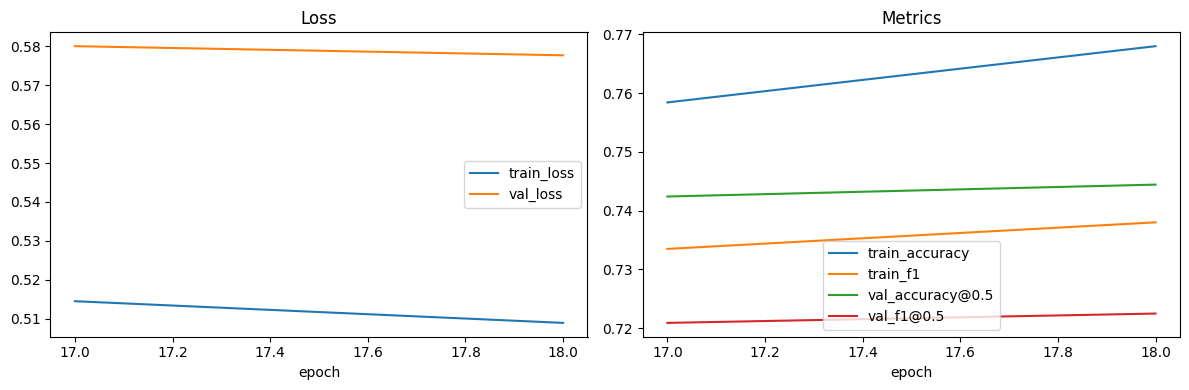

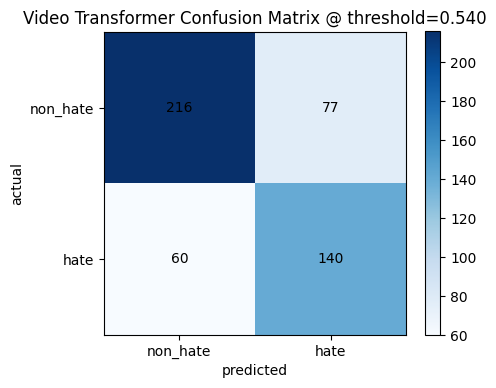

In [ ]:
history_file = REPORT_DIR / "video_transformer_history.csv"
if history_file.exists():
    history_df = pd.read_csv(history_file)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["train_accuracy"], label="train_accuracy")
    axes[1].plot(history_df["epoch"], history_df["train_f1"], label="train_f1")
    axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="val_accuracy@0.5")
    axes[1].plot(history_df["epoch"], history_df["val_f1"], label="val_f1@0.5")
    axes[1].set_title("Metrics")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(REPORT_DIR / "video_transformer_training_curves.png", dpi=160)
    plt.show()
else:
    print(f"no training history to plot for {EXPERIMENT_NAME}: {history_file}")


cm = confusion_matrix(test_y, (test_prob >= best_threshold).astype(int), labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], labels=["non_hate", "hate"])
ax.set_yticks([0, 1], labels=["non_hate", "hate"])
ax.set_xlabel("predicted")
ax.set_ylabel("actual")
ax.set_title(f"Video Transformer Confusion Matrix @ threshold={best_threshold:.3f}")
for row in range(cm.shape[0]):
    for col in range(cm.shape[1]):
        ax.text(col, row, str(cm[row, col]), ha="center", va="center", color="black")
fig.colorbar(im, ax=ax)
fig.tight_layout()
fig.savefig(REPORT_DIR / "video_transformer_confusion_matrix.png", dpi=160)
plt.show()

## Inference Utility

In [ ]:
def load_video_transformer(checkpoint_path=SAVE_CHECKPOINT_PATH):
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model_name = checkpoint.get("model_name", CFG["model_name"])
    inference_config = AutoConfig.from_pretrained(model_name)
    inference_config.num_labels = 2
    inference_config.id2label = checkpoint.get("id2label", id2label)
    inference_config.label2id = checkpoint.get("label2id", label2id)
    inference_model = VideoMAEForVideoClassification.from_pretrained(
        model_name,
        config=inference_config,
        ignore_mismatched_sizes=True,
    )
    checkpoint_cfg = checkpoint.get("config", CFG)
    inference_model = apply_classifier_dropout(inference_model, checkpoint_cfg.get("head_dropout", 0.0)).to(DEVICE)
    inference_model.load_state_dict(checkpoint["model_state_dict"])
    inference_model.eval()
    return inference_model, float(checkpoint.get("threshold", 0.5)), checkpoint.get("config", CFG)


@torch.no_grad()
def predict_materialized_video(source_video_id, split="test", checkpoint_path=SAVE_CHECKPOINT_PATH):
    inference_model, threshold, _ = load_video_transformer(checkpoint_path)
    clip_rows = materialized_clip_df[
        (materialized_clip_df["source_video_id"].astype(str) == str(source_video_id))
        & (materialized_clip_df["split"].astype(str) == str(split))
    ].copy()
    if clip_rows.empty:
        clip_rows = materialized_clip_df[materialized_clip_df["source_video_id"].astype(str) == str(source_video_id)].copy()
    if clip_rows.empty:
        raise ValueError(f"No materialized clips found for source_video_id={source_video_id}")

    logits = []
    for row in clip_rows.itertuples(index=False):
        payload = load_torch_payload(row.clip_path)
        pixel_values = adapt_clip_to_model_frames(payload["clip"], CFG["num_frames"]).unsqueeze(0).to(DEVICE)
        with autocast(device_type=DEVICE.type, enabled=USE_AMP):
            logits.append(inference_model(pixel_values=pixel_values).logits.squeeze(0).detach().cpu())
    mean_logits = torch.stack(logits, dim=0).mean(dim=0)
    prob = torch.softmax(mean_logits, dim=0)[1].item()
    return {
        "source_video_id": str(source_video_id),
        "num_clips": int(len(logits)),
        "prob_hate": float(prob),
        "threshold": float(threshold),
        "prediction": int(prob >= threshold),
    }
